In [ ]:
import pandas as pd

df = pd.read_csv("NER_dataset.csv", encoding="latin1")

print(df.head())

    Sentence #           Word  POS Tag
0  Sentence: 1      Thousands  NNS   O
1          NaN             of   IN   O
2          NaN  demonstrators  NNS   O
3          NaN           have  VBP   O
4          NaN        marched  VBN   O


In [ ]:
df.shape

(1048575, 4)

In [ ]:
df.isnull().sum()

,0
Sentence #,1000616
Word,10
POS,0
Tag,0


In [ ]:
df = df.dropna()
df = df.drop_duplicates()

# remove spaces
df.columns = df.columns.str.strip()

df["Word"] = df["Word"].astype(str).str.strip()
df["Tag"] = df["Tag"].astype(str).str.strip().str.upper()

print(df.head())

     Sentence #       Word  POS Tag
0   Sentence: 1  Thousands  NNS   O
24  Sentence: 2   Families  NNS   O
54  Sentence: 3       They  PRP   O
68  Sentence: 4     Police  NNS   O
83  Sentence: 5        The   DT   O


In [ ]:
sentences = []
labels = []

current_sentence = []
current_tags = []

prev_id = df.iloc[0]["Sentence #"]

for i in range(len(df)):
    sent_id = df.iloc[i]["Sentence #"]
    word = df.iloc[i]["Word"]
    tag = df.iloc[i]["Tag"]

    # new sentence start
    if sent_id != prev_id:
        sentences.append(" ".join(current_sentence))
        labels.append(current_tags)

        current_sentence = []
        current_tags = []

    current_sentence.append(word)
    current_tags.append(tag)

    prev_id = sent_id

# last sentence
if current_sentence:
    sentences.append(" ".join(current_sentence))
    labels.append(current_tags)

print("Total sentences:", len(sentences))

Total sentences: 47949


In [ ]:
TRAIN_DATA = []

for i in range(len(sentences)):
    text = sentences[i]
    tags = labels[i]

    entities = []
    start = 0

    words = text.split()

    for word, tag in zip(words, tags):
        end = start + len(word)

        if tag != "O":   # O = no entity
            entities.append((start, end, tag))

        start = end + 1

    TRAIN_DATA.append((text, {"entities": entities}))

print("Training samples:", len(TRAIN_DATA))

Training samples: 47949


In [ ]:
import spacy
from spacy.training.example import Example
from spacy.util import minibatch, compounding
from random import shuffle

nlp = spacy.blank("en")
ner = nlp.add_pipe("ner")

# labels add
for _, annotations in TRAIN_DATA:
    for ent in annotations["entities"]:
        ner.add_label(ent[2])

optimizer = nlp.initialize()

EPOCHS = 5   # 🔥 reduce epochs

for epoch in range(EPOCHS):
    shuffle(TRAIN_DATA)
    losses = {}

    # 🔥 BATCHING (MOST IMPORTANT FIX)
    batches = minibatch(TRAIN_DATA, size=compounding(8.0, 64.0, 1.5))

    for batch in batches:
        examples = []

        for text, ann in batch:
            doc = nlp.make_doc(text)
            examples.append(Example.from_dict(doc, ann))

        nlp.update(examples, sgd=optimizer, losses=losses)

    print(f"Epoch {epoch+1} Loss:", losses)

nlp.to_disk("ner_model")
print("Model Saved!")

Epoch 1 Loss: {'ner': np.float32(7278.7363)}
Epoch 2 Loss: {'ner': np.float32(4885.1914)}
Epoch 3 Loss: {'ner': np.float32(4253.567)}
Epoch 4 Loss: {'ner': np.float32(3947.7512)}
Epoch 5 Loss: {'ner': np.float32(3772.7507)}
Model Saved!


In [ ]:
import spacy

nlp = spacy.load("ner_model")
print("Model Loaded!")

Model Loaded!


In [ ]:
text = "Google opened office in California"

doc = nlp(text)

for ent in doc.ents:
    print(ent.text, "→", ent.label_)

Google → B-ORG
California → B-ORG


In [ ]:
text = "Ali drinking water"

doc = nlp(text)

for ent in doc.ents:
    print(ent.text, "→", ent.label_)

Ali → B-PER


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_true = []
y_pred = []

for text, ann in TRAIN_DATA[:2000]:   # ⚡ sample for speed
    doc = nlp(text)

    # true label (first entity or fallback)
    true_labels = [ent[2] for ent in ann["entities"]]
    true = true_labels[0] if len(true_labels) > 0 else "O"

    pred_labels = [ent.label_ for ent in doc.ents]
    pred = pred_labels[0] if len(pred_labels) > 0 else "O"

    y_true.append(true)
    y_pred.append(pred)

print("Accuracy:", accuracy_score(y_true, y_pred))

Accuracy: 0.95


In [ ]:
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))


Classification Report:

              precision    recall  f1-score   support

       B-EVE       0.00      0.00      0.00         1
       B-GEO       0.73      0.95      0.83       138
       B-GPE       0.91      0.92      0.91       114
       B-ORG       0.79      0.47      0.59       114
       B-PER       0.97      0.95      0.96       166
       B-TIM       0.95      0.83      0.89        24
           O       0.99      0.99      0.99      1443

    accuracy                           0.95      2000
   macro avg       0.76      0.73      0.74      2000
weighted avg       0.95      0.95      0.95      2000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


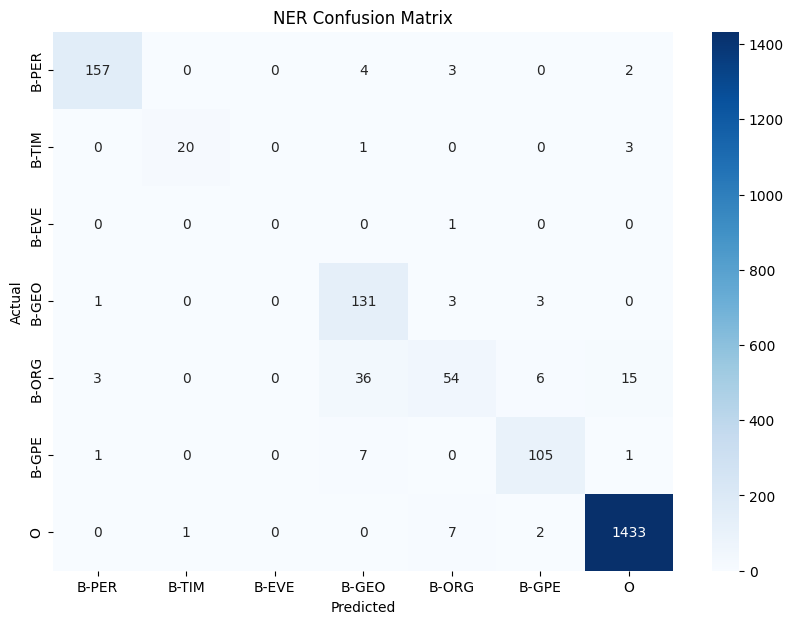

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

labels = list(set(y_true + y_pred))

cm = confusion_matrix(y_true, y_pred, labels=labels)

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("NER Confusion Matrix")
plt.show()

In [ ]:
import gradio as gr

def predict(text):
    doc = nlp(text)

    output = []
    for ent in doc.ents:
        output.append(f"{ent.text} → {ent.label_}")

    if len(output) == 0:
        return "No entities found"

    return "\n".join(output)

gr.Interface(
    fn=predict,
    inputs=gr.Textbox(lines=2, placeholder="Enter sentence..."),
    outputs="text",
    title="NER Model (spaCy)",
    theme="dark"
).launch()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/gradio/blocks.py:1143: UserWarning: Cannot load dark. Caught Exception: Client error '404 Not Found' for url 'https://huggingface.co/api/spaces/dark' (Request ID: Root=1-6a1cae27-0384049c40663f28173e764b;062951ac-deb7-46e4-8039-0fc98677dc5a)
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/404

Sorry, we can't find the page you are looking for.
  warnings.warn(f"Cannot load {theme}. Caught Exception: {

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b7a5a5a79d444243de.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import shutil
import os

# model save already done by spaCy
nlp.to_disk("ner_model")

print("Model saved!")

Model saved!


In [ ]:
import shutil

shutil.make_archive("ner_model", "zip", "ner_model")

print("ZIP created: ner_model.zip")
from google.colab import files
files.download("ner_model.zip")

ZIP created: ner_model.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>